# Unified Framework Demo: Same Strategy, Backtest to Live

**Docker image**: `ml4t`

The expensive failure in deploying a strategy is not a bad model. It is two implementations of the
same idea: one written for the backtester and one rewritten for the live path, differing in a
detail nobody noticed until money was on it. Every difference between them is a bug that the
backtest cannot find, because the backtest is not running the code that trades.

The framework this chapter uses avoids that by construction: one `Strategy` class, two engines. This
notebook is the test of that claim rather than a statement of it. The same class runs through
`ml4t.backtest.Engine` and through `ml4t.live.LiveEngine` over the same bars, and the two signal
tapes are compared field by field. A mismatch is a framework defect, and the comparison is written
so it would say so.

**Learning Objectives**:
- Run one `Strategy` subclass through both engines without changing a line of it
- Compare two signal tapes field by field, and fail the comparison rather than describe it
- Say what a parity test on replayed bars establishes, and what it leaves untested

**Book Reference**: Chapter 25, Section 25.1 (The unified framework advantage)

**Prerequisites**: The `Strategy` interface, and the distinction between an engine that pulls bars
from history and one that receives them from a feed.

## Setup

Everything below is arranged to make one thing vary. The strategy, the bars, the parameters and the
fill convention are held fixed across the two runs so that a difference in output has one candidate
explanation left, which is the engine.

One warning filter is installed with the imports. The broker adapters pull in websockets' legacy
module, which deprecates itself on import; it is the library's business rather than this
notebook's and nothing in the result depends on it. The other import-time deprecation, from
`nest_asyncio`, is filtered inside `async_utils.run_async` where the call that triggers it lives.

In [1]:
"""Verify backtest-to-live signal parity with a single strategy class."""

import asyncio
import logging
import warnings
from collections.abc import AsyncIterator
from datetime import datetime
from typing import Any

import matplotlib.pyplot as plt
import pandas as pd
import polars as pl
from async_utils import run_async

warnings.filterwarnings("ignore", category=DeprecationWarning, module=r"websockets\.legacy")

from ml4t.backtest import BacktestConfig, DataFeed, Engine, ExecutionMode, Strategy
from ml4t.backtest.types import Order, OrderSide, OrderStatus, OrderType, Position
from ml4t.live import (
    LiveEngine,
    VirtualPortfolio,
)

from data import load_etfs
from utils.style import COLORS, add_message_title, show_with_alt

logging.basicConfig(
    level=logging.WARNING,
    format="%(asctime)s - %(name)s - %(levelname)s - %(message)s",
)

## 1. Settings

Every one of these is held identical across the two runs, which is what makes the comparison a
test of the engines.

`START_DATE` and `END_DATE` bound a year of daily bars, long enough for a 30-day average to warm
up and produce a handful of crossings.

`FAST_MA` and `SLOW_MA` are the two averaging windows in sessions. Ten against thirty is a
conventional pairing and nothing here depends on it; the parity claim holds or fails at any
setting, which is the point.

`MAX_SYMBOLS` caps how many of the three ETFs are loaded, and zero means all of them. It exists so
a shorter run can be requested without editing the notebook. The strategy trades only SPY at any
setting; the other two are loaded so the data path carries more than one symbol, which is what
makes the feed's per-symbol handling part of what the comparison covers.

`INITIAL_CASH` sizes the account. It scales the printed portfolio values and changes nothing about
which signals fire, since the strategy trades a fixed hundred shares.

In [2]:
MAX_SYMBOLS = 0
START_DATE = "2023-01-01"
END_DATE = "2024-01-01"

In [3]:
ALL_SYMBOLS = ["SPY", "QQQ", "IWM"]
SYMBOLS = ALL_SYMBOLS[:MAX_SYMBOLS] if MAX_SYMBOLS > 0 else ALL_SYMBOLS.copy()
INITIAL_CASH = 100_000
FAST_MA = 10
SLOW_MA = 30

print(f"Symbols: {SYMBOLS}")
print(f"Period: {START_DATE} to {END_DATE}")

Symbols: ['SPY', 'QQQ', 'IWM']
Period: 2023-01-01 to 2024-01-01


## 2. Data Acquisition

One load, one filter, one cleaning step, and both engines read the result. The shared tape is the
notebook's control variable: if the two engines saw different bars, a later signal mismatch would
say nothing about either of them.

In [4]:
print("Loading ETF data from canonical source...")
etf_data = load_etfs()

# Filter to the demo symbols and date range
etf_filtered = etf_data.filter(
    (pl.col("symbol").is_in(SYMBOLS))
    & (pl.col("timestamp") >= pl.lit(START_DATE).str.to_date())
    & (pl.col("timestamp") <= pl.lit(END_DATE).str.to_date())
).sort("timestamp")

# Convert to yfinance-like MultiIndex format for compatibility with rest of notebook
# Pivot each column separately and combine
ohlcv_cols = ["open", "high", "low", "close", "volume"]
raw_data_dict = {}
for col in ohlcv_cols:
    pivot = (
        etf_filtered.select(["timestamp", "symbol", col])
        .pivot(on="symbol", index="timestamp", values=col)
        .sort("timestamp")
        .to_pandas()
        .set_index("timestamp")
    )
    raw_data_dict[col.title()] = pivot

# Create MultiIndex columns similar to yfinance output
raw_data = pd.concat(raw_data_dict, axis=1)
raw_data = raw_data.ffill().dropna()
raw_data.index = pd.to_datetime(raw_data.index, utc=True)

# Update SYMBOLS to only include available symbols
available_symbols = [s for s in SYMBOLS if s in raw_data["Close"].columns]
SYMBOLS = available_symbols

print(f"Loaded {len(raw_data):,} daily bars for {len(SYMBOLS)} symbols")

# Store close prices for strategy signals (used later for comparison)
close_prices = raw_data["Close"].ffill()

Loading ETF data from canonical source...
Loaded 250 daily bars for 3 symbols


Both engines will read from `raw_data` and nothing else. Holding the tape fixed is what makes the
rest of the notebook a test of the engines rather than a comparison of two datasets.

## 3. One Strategy Implementation

A **dual moving average crossover**: buy when the shorter average rises above the longer one and
sell when it falls back below. The two averages summarise recent and less recent price, so a
crossing is the shorter horizon disagreeing with the longer one about direction.

The strategy is chosen for being uninteresting. Every line of it is visible below, it holds no
state a reader cannot follow, and it has no parameters worth tuning. That is what makes a later
difference between the two engines attributable to the engines.

In [5]:
class DualMAStrategy(Strategy):
    """Dual moving average crossover, written once for both engines.

    Both engines call the same `on_data` with the same arguments, which is the
    property the rest of the notebook tests rather than assumes.

    Attributes:
        fast_period: Sessions in the shorter average
        slow_period: Sessions in the longer average
        signal_log: Records all signals for verification
    """

    def __init__(self, symbol: str, fast_period: int, slow_period: int):
        self.symbol = symbol
        self.fast_period = fast_period
        self.slow_period = slow_period

        # Price history for MA calculation
        self.prices: list[float] = []

        # Signal log for comparison
        self.signal_log: list[dict] = []

    def on_start(self, broker):
        """Called when engine starts."""
        self.prices = []
        self.signal_log = []

    def on_data(self, timestamp: datetime, data: dict, context: dict, broker):
        """Process one bar and emit a signal when the averages cross.

        Args:
            timestamp: Bar timestamp
            data: {symbol: {'open', 'high', 'low', 'close', 'volume'}}
            context: Additional metadata
            broker: Broker interface (sync in both modes)
        """
        # Get bar for our symbol
        bar = data.get(self.symbol)
        if not bar:
            return

        close = bar["close"]
        self.prices.append(close)

        # Need enough history for slow MA
        if len(self.prices) < self.slow_period:
            return

        # Calculate moving averages
        fast_ma = sum(self.prices[-self.fast_period :]) / self.fast_period
        slow_ma = sum(self.prices[-self.slow_period :]) / self.slow_period

        # Get current position
        position = broker.get_position(self.symbol)
        has_position = position is not None and position.quantity > 0

        # Generate signal
        signal = None
        if fast_ma > slow_ma and not has_position:
            signal = "BUY"
            broker.submit_order(self.symbol, 100, side=OrderSide.BUY)

        elif fast_ma < slow_ma and has_position:
            signal = "SELL"
            broker.submit_order(self.symbol, 100, side=OrderSide.SELL)

        # Log signal for comparison
        if signal:
            self.signal_log.append(
                {
                    "timestamp": timestamp,
                    "symbol": self.symbol,
                    "signal": signal,
                    "fast_ma": round(fast_ma, 2),
                    "slow_ma": round(slow_ma, 2),
                    "price": round(close, 2),
                }
            )

    def on_end(self, broker):
        """Called when engine stops."""
        pass

## 4. Backtest Mode

`ml4t.backtest.Engine` runs first and produces the reference tape the replay has to match.

In [6]:
# Prepare data for backtest engine (long format)
data_records = []
for date in raw_data.index:
    for symbol in SYMBOLS:
        if pd.notna(raw_data["Close"].loc[date, symbol]):
            data_records.append(
                {
                    "timestamp": date.to_pydatetime(),
                    "symbol": symbol,
                    "open": float(raw_data["Open"].loc[date, symbol]),
                    "high": float(raw_data["High"].loc[date, symbol]),
                    "low": float(raw_data["Low"].loc[date, symbol]),
                    "close": float(raw_data["Close"].loc[date, symbol]),
                    "volume": float(raw_data["Volume"].loc[date, symbol]),
                }
            )

prices_df = pl.DataFrame(data_records)
print(f"Prepared {len(prices_df):,} price records for backtest")

Prepared 750 price records for backtest


The engines take their bars in different shapes: the backtest reads a long frame of one row per
symbol and date, and the replay feed below yields one dict per bar. That difference is unavoidable
and it is exactly the seam a parity test has to cross. Both are built from `raw_data`, so a
mismatch downstream cannot be a difference in the prices themselves.


In [7]:
# Create backtest components
feed_backtest = DataFeed(prices_df=prices_df)
strategy_backtest = DualMAStrategy(symbol="SPY", fast_period=FAST_MA, slow_period=SLOW_MA)

engine_backtest = Engine(
    feed=feed_backtest,
    strategy=strategy_backtest,
    config=BacktestConfig(
        initial_cash=INITIAL_CASH,
        # The replay broker also fills at the finalized current close. SAME_BAR
        # therefore isolates engine/strategy parity. This is not a performance
        # estimate and makes no claim about executable close prices.
        execution_mode=ExecutionMode.SAME_BAR,
        commission_rate=0.0005,
    ),
)

# Run backtest
results = engine_backtest.run()

print(f"Final value:       ${results['final_value']:,.2f}")
print(f"Total return:      {results['total_return_pct']:.2f}%")
print(f"Total trades:      {results['num_trades']}")
print(f"Signals generated: {len(strategy_backtest.signal_log)}")

backtest_signals = strategy_backtest.signal_log.copy()

Final value:       $105,234.61
Total return:      5.23%
Total trades:      4
Signals generated: 9


The signal count and the trade count differ, and the gap is worth reading rather than skipping. A
signal here is an order; a trade in the analyzer's sense is a completed round trip. The strategy
alternates buy and sell, so an odd number of signals means one position is still open when the data
runs out, and the trade count is one less than the number of entries. Any notebook that prints the
two next to each other owes the reader that sentence, because "orders went missing" is the other
reading.

## 5. What the Live Path Needs

`LiveEngine` does not know where its bars come from or who fills its orders. It needs two objects:
something satisfying the broker protocol and something satisfying the feed protocol. Supplying a
simulated broker and a feed that replays history is what lets the live path be tested at all,
without a broker connection and outside market hours.

Both are deliberately minimal. The broker fills every order immediately at the current close, and
the feed yields finished bars with no delay. Those choices remove execution and timing from the
comparison, which is the point here and the limitation stated at the end.

In [8]:
class SimulatedBroker:
    """Simulated broker for demo purposes.

    Implements AsyncBrokerProtocol to work with LiveEngine.
    Uses VirtualPortfolio for realistic position tracking.
    """

    def __init__(self, initial_cash: float = 100_000.0):
        self._portfolio = VirtualPortfolio(initial_cash=initial_cash)
        self._connected = False
        self._pending_orders: list[Order] = []
        self._order_count = 0

        # Current prices for market orders
        self._current_prices: dict[str, float] = {}
        self._current_timestamp: datetime | None = None

    async def connect(self) -> None:
        """Connect (no-op for simulation)."""
        self._connected = True

    async def disconnect(self) -> None:
        """Disconnect (no-op for simulation)."""
        self._connected = False

    async def is_connected_async(self) -> bool:
        return self._connected

    @property
    def positions(self) -> dict[str, Position]:
        return self._portfolio.positions

    @property
    def pending_orders(self) -> list[Order]:
        return self._pending_orders

    @property
    def is_connected(self) -> bool:
        return self._connected

    def get_position(self, asset: str) -> Position | None:
        return self._portfolio.positions.get(asset)

    async def get_positions_async(self) -> dict[str, Position]:
        return self._portfolio.positions

    async def get_pending_orders_async(self) -> list[Order]:
        return self._pending_orders

    async def get_position_async(self, asset: str) -> Position | None:
        return self.get_position(asset)

    async def get_account_value_async(self) -> float:
        return self._portfolio.account_value

    async def get_cash_async(self) -> float:
        return self._portfolio.cash

    def update_price(self, asset: str, price: float, timestamp: datetime) -> None:
        """Update current price for market orders."""
        self._current_prices[asset] = price
        self._current_timestamp = timestamp
        self._portfolio.update_prices({asset: price})

    async def submit_order_async(
        self,
        asset: str,
        quantity: int,
        side: OrderSide | None = None,
        order_type: OrderType = OrderType.MARKET,
        limit_price: float | None = None,
        stop_price: float | None = None,
        **kwargs,
    ) -> Order:
        """Submit and immediately fill order (simulation)."""
        if side is None:
            side = OrderSide.BUY if quantity > 0 else OrderSide.SELL
            quantity = abs(quantity)

        if limit_price is not None:
            price = limit_price
        elif asset in self._current_prices:
            price = self._current_prices[asset]
        else:
            raise KeyError(
                f"No price for {asset}: the feed has not delivered a bar for it. "
                "Filling at a default would put a price into the tape that no bar carried."
            )

        self._order_count += 1
        fill_timestamp = self._current_timestamp or datetime.min

        # Create filled order
        order = Order(
            asset=asset,
            side=side,
            quantity=quantity,
            order_type=order_type,
            limit_price=limit_price,
            stop_price=stop_price,
            order_id=f"SIM-{self._order_count:04d}",
            status=OrderStatus.FILLED,
            filled_quantity=quantity,
            filled_price=price,
            filled_at=fill_timestamp,
        )

        # Update portfolio
        self._portfolio.process_fill(order)

        return order

    async def cancel_order_async(self, order_id: str) -> bool:
        return False

    async def close_position_async(self, asset: str) -> Order | None:
        pos = self.get_position(asset)
        if pos and pos.quantity != 0:
            side = OrderSide.SELL if pos.quantity > 0 else OrderSide.BUY
            return await self.submit_order_async(asset, abs(pos.quantity), side)
        return None

### Historical Replay Feed

The historical replay feed is the notebook's stand-in for a real streaming source. Its job is to
preserve live-engine semantics while holding the market data constant.

A missing bar raises here rather than being skipped. The parity claim rests on both engines
reading the same tape, so a feed that quietly dropped a symbol on some dates would hand the live
engine a shorter history, move its moving averages, and report the difference as an engine
disagreement.

In [9]:
class HistoricalReplayFeed:
    """Replays historical data as a live feed.

    Implements DataFeedProtocol for use with LiveEngine.
    Enables live mode demos without requiring market hours.
    """

    def __init__(
        self,
        data: pd.DataFrame,
        symbols: list[str],
        broker: SimulatedBroker | None = None,
    ):
        """Initialize replay feed.

        Args:
            data: DataFrame with OHLCV data (MultiIndex columns: metric, symbol)
            symbols: List of symbols to include
            broker: Optional broker to update prices
        """
        self._data = data
        self._symbols = symbols
        self._broker = broker
        self._running = False
        self._index = 0
        self._dates = list(data.index)
        self._stats = {"bars_emitted": 0}

    async def start(self) -> None:
        """Start the feed."""
        self._running = True
        self._index = 0

    def stop(self) -> None:
        """Stop the feed."""
        self._running = False

    @property
    def stats(self) -> dict[str, Any]:
        return self._stats

    def __aiter__(
        self,
    ) -> AsyncIterator[tuple[datetime, dict[str, dict[str, Any]], dict[str, Any]]]:
        return self

    async def __anext__(
        self,
    ) -> tuple[datetime, dict[str, dict[str, Any]], dict[str, Any]]:
        """Get next bar."""
        if not self._running or self._index >= len(self._dates):
            raise StopAsyncIteration

        date = self._dates[self._index]
        self._index += 1

        timestamp = date.to_pydatetime() if hasattr(date, "to_pydatetime") else date
        data: dict[str, dict[str, Any]] = {}
        for symbol in self._symbols:
            bar = {
                field.lower(): float(self._data[field.title()].loc[date, symbol])
                for field in ("open", "high", "low", "close", "volume")
            }
            data[symbol] = bar
            if self._broker:
                self._broker.update_price(symbol, bar["close"], timestamp)

        self._stats["bars_emitted"] += 1

        # Yield to the event loop, as a real feed would while waiting on the socket.
        await asyncio.sleep(0)

        return timestamp, data, {}

## 6. Live Mode

The same strategy class, constructed fresh so it starts with no history, running through
`LiveEngine` over the same bars.

In [10]:
async def run_live_mode():
    """Run strategy in live mode with historical replay."""
    # The raw broker, not SafeBroker: risk controls could reject an order and turn a parity
    # test into a test of the controls. 10_safety_risk_demo adds them.
    broker = SimulatedBroker(initial_cash=INITIAL_CASH)

    # Create historical replay feed
    feed = HistoricalReplayFeed(data=raw_data, symbols=SYMBOLS, broker=broker)

    strategy_live = DualMAStrategy(symbol="SPY", fast_period=FAST_MA, slow_period=SLOW_MA)

    # Create LiveEngine
    engine = LiveEngine(
        strategy=strategy_live,
        broker=broker,
        feed=feed,
    )

    # Connect and run
    await engine.connect()

    try:
        await engine.run()
    finally:
        await engine.stop()

    print(f"Bars processed:    {engine.stats['bar_count']}")
    print(f"Signals generated: {len(strategy_live.signal_log)}")

    return strategy_live.signal_log


# Run async live mode
live_signals = run_async(run_live_mode())

2026-09-10 20:15:16,686 - ml4t.live.engine - WARNING - LiveEngine: Feed terminated


2026-09-10 20:15:16,686 - ml4t.live.engine - WARNING - LiveEngine: Runtime degraded (feed_terminated) and auto recovery disabled


Bars processed:    250
Signals generated: 9


The engine logs a warning when the feed stops, and the run above shows it: `feed_terminated`,
`runtime degraded`, `auto recovery disabled`. That is correct behaviour and worth pausing on. In
production a feed that stops delivering is a fault, and an engine that carried on quietly would be
trading on stale prices. In a replay it is the last bar of the file. The engine cannot tell the two
apart, and neither can a monitoring rule built on that log line, which is one reason a replayed
live path is a parity test rather than a rehearsal.

## 7. The Comparison

Did the two engines produce the same signals on the same tape? Everything before this cell exists
to make that question answerable and the answer attributable.

In [11]:
print(f"Backtest signals: {len(backtest_signals)}")
print(f"Live signals:     {len(live_signals)}")

# Falsifiability gate: a different count of signals is itself a parity
# failure. The pairwise comparison only makes sense after the counts
# match, so raise immediately if they don't.
assert len(backtest_signals) == len(live_signals), (
    f"Signal count mismatch: backtest={len(backtest_signals)} "
    f"vs live={len(live_signals)} - the engines disagree on the "
    "signal tape, not just on signal values."
)

Backtest signals: 9
Live signals:     9


Build a single comparison frame keyed by signal index with the
`engine`, `timestamp`, `symbol`, `side`, `price`, `fast_ma`, `slow_ma`,
and a `match` column that is True only when every field agrees within
the tolerance. The frame is the audit surface a mismatch would land on.

In [12]:
def _rows_for(engine: str, signals: list[dict]) -> list[dict]:
    return [
        {
            "engine": engine,
            "i": i,
            "timestamp": sig["timestamp"],
            "symbol": "SPY",
            "side": sig["signal"],
            "price": sig["price"],
            "fast_ma": sig["fast_ma"],
            "slow_ma": sig["slow_ma"],
        }
        for i, sig in enumerate(signals)
    ]


comparison = pl.DataFrame(
    _rows_for("backtest", backtest_signals) + _rows_for("live", live_signals)
).sort(["i", "engine"])

# Pivot to one row per signal index and compare every recorded field.
pairs = (
    comparison.pivot(
        values=["timestamp", "symbol", "side", "price", "fast_ma", "slow_ma"],
        index="i",
        on="engine",
    )
    .with_columns(
        match=(
            (pl.col("timestamp_backtest") == pl.col("timestamp_live"))
            & (pl.col("symbol_backtest") == pl.col("symbol_live"))
            & (pl.col("side_backtest") == pl.col("side_live"))
            & ((pl.col("price_backtest") - pl.col("price_live")).abs() < 0.01)
            & ((pl.col("fast_ma_backtest") - pl.col("fast_ma_live")).abs() < 0.01)
            & ((pl.col("slow_ma_backtest") - pl.col("slow_ma_live")).abs() < 0.01)
        ),
    )
    .sort("i")
)

matches = int(pairs["match"].sum())
print(f"Matching signals: {matches}/{len(backtest_signals)}")
if matches != len(backtest_signals):
    print("\nFirst three mismatches:")
    print(pairs.filter(~pl.col("match")).head(3))

# Side-by-side comparison frame for the reader (engine-tagged rows).
comparison.head(10)

Matching signals: 9/9


engine,i,timestamp,symbol,side,price,fast_ma,slow_ma
str,i64,"datetime[μs, UTC]",str,str,f64,f64,f64
"""backtest""",0,2023-02-14 00:00:00 UTC,"""SPY""","""BUY""",395.58,394.6,383.78
"""live""",0,2023-02-14 00:00:00 UTC,"""SPY""","""BUY""",395.58,394.6,383.78
"""backtest""",1,2023-02-28 00:00:00 UTC,"""SPY""","""SELL""",379.87,386.41,387.51
"""live""",1,2023-02-28 00:00:00 UTC,"""SPY""","""SELL""",379.87,386.41,387.51
"""backtest""",2,2023-03-30 00:00:00 UTC,"""SPY""","""BUY""",388.48,381.15,380.85
"""live""",2,2023-03-30 00:00:00 UTC,"""SPY""","""BUY""",388.48,381.15,380.85
"""backtest""",3,2023-05-15 00:00:00 UTC,"""SPY""","""SELL""",397.44,395.5,395.6
"""live""",3,2023-05-15 00:00:00 UTC,"""SPY""","""SELL""",397.44,395.5,395.6
"""backtest""",4,2023-05-17 00:00:00 UTC,"""SPY""","""BUY""",399.58,396.13,395.79


The comparison is the notebook's whole claim, and it is written to fail. An unequal signal count
raises before anything is compared field by field, and every field of every matched pair has to
agree. Nothing here reports a similarity score: the framework either produced the same tape twice
or it did not.

## 8. The Signal Logs

The count and the field comparison say whether the tapes match. The logs say what the tapes are.

In [13]:
def _signals_to_frame(signals: list[dict]) -> pl.DataFrame:
    """Render the signal log as a polars frame for side-by-side display."""
    rows = []
    for sig in signals:
        ts = sig["timestamp"]
        ts_str = ts.strftime("%Y-%m-%d") if hasattr(ts, "strftime") else str(ts)[:10]
        rows.append(
            {
                "date": ts_str,
                "signal": sig["signal"],
                "price": round(sig["price"], 2),
                "fast_ma": round(sig["fast_ma"], 2),
                "slow_ma": round(sig["slow_ma"], 2),
            }
        )
    return pl.DataFrame(rows)

In [14]:
backtest_log = _signals_to_frame(backtest_signals).head(5)
backtest_log

date,signal,price,fast_ma,slow_ma
str,str,f64,f64,f64
"""2023-02-14""","""BUY""",395.58,394.6,383.78
"""2023-02-28""","""SELL""",379.87,386.41,387.51
"""2023-03-30""","""BUY""",388.48,381.15,380.85
"""2023-05-15""","""SELL""",397.44,395.5,395.6
"""2023-05-17""","""BUY""",399.58,396.13,395.79


In [15]:
live_log = _signals_to_frame(live_signals).head(5)
live_log

date,signal,price,fast_ma,slow_ma
str,str,f64,f64,f64
"""2023-02-14""","""BUY""",395.58,394.6,383.78
"""2023-02-28""","""SELL""",379.87,386.41,387.51
"""2023-03-30""","""BUY""",388.48,381.15,380.85
"""2023-05-15""","""SELL""",397.44,395.5,395.6
"""2023-05-17""","""BUY""",399.58,396.13,395.79


The two logs are printed separately rather than merged so that a reader comparing them by eye is
doing the same thing the assertion above did mechanically. When a parity test fails, this is where
the failure becomes a date and a moving-average value rather than a count.

## Where the Strategy Traded

The tables above show the first rows of each log. The question they cannot answer is where the
crossovers fell across the year, which is a judgement about a shape: whether the strategy traded
steadily or clustered around a few reversals, and whether the two engines fired at the same
moments or merely the same number of times.

Drawing the year answers both. The two moving averages cross where the signals sit, and each
engine's markers are drawn separately: filled for the backtest, hollow rings on top for the live
replay. Every ring lands on a marker when the tapes agree, and a ring standing alone is a signal
one engine produced and the other did not.

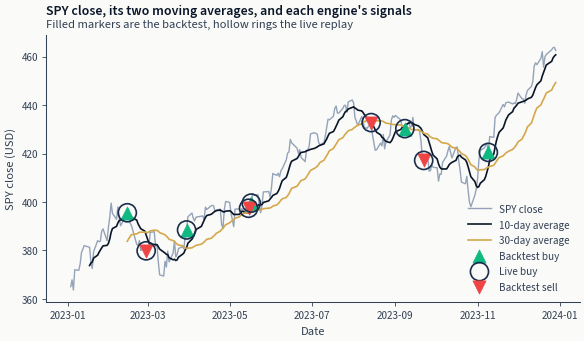

In [16]:
spy_close = close_prices["SPY"]
fast_line = spy_close.rolling(FAST_MA).mean()
slow_line = spy_close.rolling(SLOW_MA).mean()


def _marker_series(signals: list[dict], side: str) -> tuple[list, list]:
    """Return the timestamps and prices of one side's signals."""
    picked = [s for s in signals if s["signal"] == side]
    return [s["timestamp"] for s in picked], [s["price"] for s in picked]


fig, ax = plt.subplots()
# The close recedes: it is the backdrop the averages are read against, and drawing it in the same
# dark as the fast average makes the two indistinguishable at this line width.
ax.plot(
    spy_close.index, spy_close.to_numpy(), color=COLORS["recede"], linewidth=1, label="SPY close"
)
ax.plot(
    fast_line.index,
    fast_line.to_numpy(),
    color=COLORS["blue"],
    linewidth=1.2,
    label=f"{FAST_MA}-day average",
)
ax.plot(
    slow_line.index,
    slow_line.to_numpy(),
    color=COLORS["amber"],
    linewidth=1.2,
    label=f"{SLOW_MA}-day average",
)

for side, marker, color in [("BUY", "^", COLORS["positive"]), ("SELL", "v", COLORS["negative"])]:
    bx, by = _marker_series(backtest_signals, side)
    lx, ly = _marker_series(live_signals, side)
    ax.scatter(bx, by, marker=marker, s=90, color=color, zorder=3, label=f"Backtest {side.lower()}")
    ax.scatter(
        lx,
        ly,
        marker="o",
        s=170,
        facecolors="none",
        edgecolors=COLORS["slate"],
        linewidths=1.2,
        zorder=4,
        label=f"Live {side.lower()}" if side == "BUY" else None,
    )

ax.set_xlabel("Date")
ax.set_ylabel("SPY close (USD)")
add_message_title(
    ax,
    "SPY close, its two moving averages, and each engine's signals",
    subtitle="Filled markers are the backtest, hollow rings the live replay",
)
ax.legend(loc="lower right", fontsize=8)
show_with_alt(
    fig,
    f"SPY close for {START_DATE} to {END_DATE} with its {FAST_MA}-day and {SLOW_MA}-day moving "
    f"averages. {len(backtest_signals)} crossover signals are marked, buys pointing up and sells "
    "pointing down, each with a hollow ring drawn from the live replay's own signal list. "
    + (
        "Every ring sits on a marker."
        if matches == len(backtest_signals)
        else "Some rings stand alone, with no marker underneath."
    ),
)

## Key Takeaways

1. **One class, two engines, and a test rather than a promise.** The value of the unified
   framework is that the code you backtested is the code that trades. That is a claim about a
   codebase, and the only thing that establishes it is a comparison that could have failed.
2. **Compare the tape, not the summary.** Two runs can agree on final value and disagree about
   when they traded. The comparison here is field by field over every signal, and it asserts
   rather than describes: an unequal count raises before the rest of the cell runs.
3. **A parity oracle is not a performance estimate.** Same-bar fills at the close are chosen to
   remove execution as a source of difference. They are not a claim that those prices were
   obtainable, and the returns printed here are not a backtest result anybody should quote.
4. **Signals are not trades.** The strategy emits an order per crossover; the analyzer counts
   completed round trips. Two different numbers, both correct, and a reader owed the distinction.
5. **A feed that ends is a fault in production and the end of the file in a replay.** The live
   engine logs the same warning either way. Anything that replays historical data through a live
   path inherits that ambiguity, and a monitoring rule that cannot tell them apart will page
   someone at the end of every backfill.

**What this does not establish.** One symbol, one year of daily bars, one strategy. The replay
feed hands the engine a finished bar with no latency, no partial fills, no rejected orders and no
disconnections, so nothing here says the two engines agree once any of those exist. That is what
[`07_order_state_machine`](07_order_state_machine.ipynb),
[`08_pipeline_verification`](08_pipeline_verification.ipynb) and
[`12_ib_basket_rebalance_demo`](12_ib_basket_rebalance_demo.ipynb) are for. And parity is not
quality: two engines agreeing on a bad strategy agree exactly as well.

**Next**: [`08_pipeline_verification`](08_pipeline_verification.ipynb) turns this comparison into
a regression test, and [`10_safety_risk_demo`](10_safety_risk_demo.ipynb) adds the broker-side
controls the live path here deliberately omits.

In [17]:
parity = "identical" if matches == len(backtest_signals) == len(live_signals) else "divergent"
print(f"Backtest final value: ${results['final_value']:,.2f}")
print(f"Signal tapes:         {parity} ({matches}/{len(backtest_signals)} fields match)")

Backtest final value: $105,234.61
Signal tapes:         identical (9/9 fields match)
